<a href="https://colab.research.google.com/github/nikolisaku1/Parallel-Programming-ML-Project/blob/main/MiniProjectParallelProgramming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy matplotlib

  Parallel ML Training Demo
  Sequential vs. Multiprocessing

Dataset: 32 mini-batches, 64 samples each
Model:   1,000 parameters (simulated)
Work:    ~100ms per batch (gradient computation)
System:  2 CPU cores available

▶  Running SEQUENTIAL training...
   ✓ Sequential time: 3.23s

▶  Running PARALLEL training...
   ✓ Parallel time (2 workers): 1.77s

  RESULTS
  Sequential time   : 3.23s
  Parallel time     : 1.77s
  Actual speedup    : 1.82×
  Ideal speedup     : 2.00×  (with 2 workers)
  Parallel efficiency: 91.0%

  → Speedup is less than ideal because of:
     • Process startup overhead
     • Data serialization (pickle) between processes
     • Gradient aggregation (sequential barrier)
     This illustrates Amdahl's Law in practice!

▶  Running scaling experiment (1 to N workers)...
   Workers:  1 → time: 3.29s  speedup: 0.98×
   Workers:  2 → time: 1.66s  speedup: 1.94×

✅ Plot saved to speedup_results.png

Done! Use the plot in your presentation to show real Amdahl's Law.


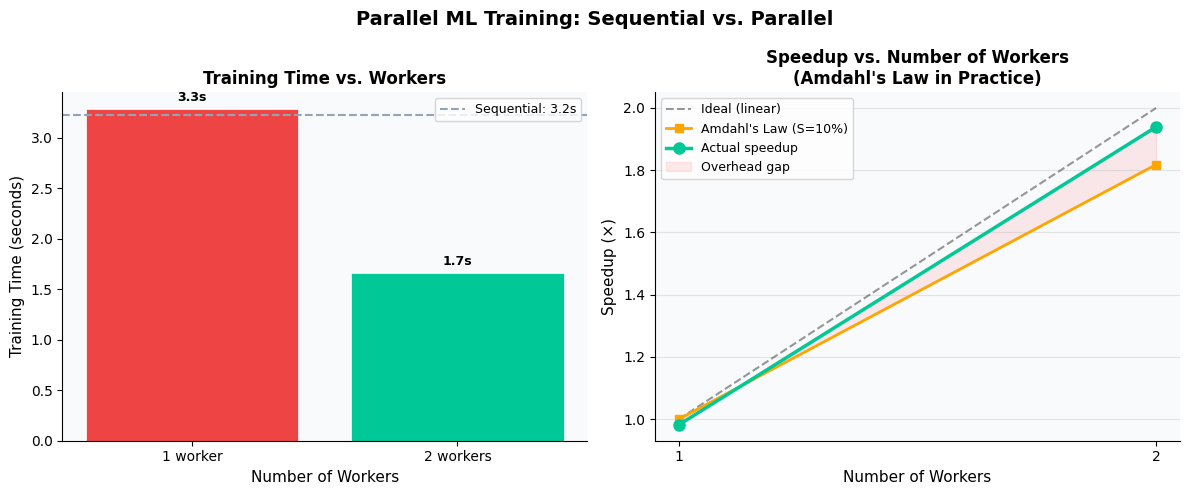

In [2]:
"""
Mini-Project: Sequential vs. Parallel ML Training Demo
=======================================================
Parallel Machine Learning Algorithms — Group Presentation

This script demonstrates the speedup gained by parallelizing
the gradient computation step of a neural network training loop.

We simulate:
  - A dataset split into 32 mini-batches
  - Each batch takes ~100ms to process (gradient computation)
  - Compare sequential processing vs multiprocessing Pool

Requirements: Python 3.7+, numpy (pip install numpy)
"""

import time
import numpy as np
from multiprocessing import Pool, cpu_count
import matplotlib.pyplot as plt


# ──────────────────────────────────────────────
# Simulated "worker": computes gradient for one batch
# ──────────────────────────────────────────────
def compute_gradient(batch_data):
    """
    Simulates the backward pass (gradient computation) for one mini-batch.
    In real ML: this involves chain-rule derivatives across all layers.
    Here we simulate 100ms of work and return a fake gradient vector.
    """
    np.random.seed(batch_data["id"])           # reproducible
    time.sleep(0.1)                            # simulate 100ms GPU-like work
    # Simulate computing gradients for a model with 1000 parameters
    gradient = np.random.randn(1000) * 0.01
    return gradient


def aggregate_gradients(gradients):
    """Average all worker gradients — this is what AllReduce does."""
    return np.mean(gradients, axis=0)


# ──────────────────────────────────────────────
# Build a fake dataset of 32 mini-batches
# ──────────────────────────────────────────────
NUM_BATCHES = 32
batches = [{"id": i, "data": np.random.randn(64, 28, 28)} for i in range(NUM_BATCHES)]

print("=" * 60)
print("  Parallel ML Training Demo")
print("  Sequential vs. Multiprocessing")
print("=" * 60)
print(f"\nDataset: {NUM_BATCHES} mini-batches, 64 samples each")
print(f"Model:   1,000 parameters (simulated)")
print(f"Work:    ~100ms per batch (gradient computation)")
print(f"System:  {cpu_count()} CPU cores available\n")


# ──────────────────────────────────────────────
# 1. SEQUENTIAL TRAINING
# ──────────────────────────────────────────────
print("▶  Running SEQUENTIAL training...")
t_start = time.time()

seq_gradients = [compute_gradient(b) for b in batches]
model_update_seq = aggregate_gradients(seq_gradients)

seq_time = time.time() - t_start
print(f"   ✓ Sequential time: {seq_time:.2f}s")


# ──────────────────────────────────────────────
# 2. PARALLEL TRAINING (multiprocessing)
# ──────────────────────────────────────────────
print("\n▶  Running PARALLEL training...")
num_workers = cpu_count()
t_start = time.time()

with Pool(processes=num_workers) as pool:
    par_gradients = pool.map(compute_gradient, batches)

model_update_par = aggregate_gradients(par_gradients)

par_time = time.time() - t_start
print(f"   ✓ Parallel time ({num_workers} workers): {par_time:.2f}s")


# ──────────────────────────────────────────────
# 3. RESULTS
# ──────────────────────────────────────────────
speedup = seq_time / par_time
ideal_speedup = num_workers
efficiency = (speedup / ideal_speedup) * 100

print("\n" + "=" * 60)
print("  RESULTS")
print("=" * 60)
print(f"  Sequential time   : {seq_time:.2f}s")
print(f"  Parallel time     : {par_time:.2f}s")
print(f"  Actual speedup    : {speedup:.2f}×")
print(f"  Ideal speedup     : {ideal_speedup:.2f}×  (with {num_workers} workers)")
print(f"  Parallel efficiency: {efficiency:.1f}%")
print(f"\n  → Speedup is less than ideal because of:")
print(f"     • Process startup overhead")
print(f"     • Data serialization (pickle) between processes")
print(f"     • Gradient aggregation (sequential barrier)")
print(f"     This illustrates Amdahl's Law in practice!")


# ──────────────────────────────────────────────
# 4. SCALING EXPERIMENT: vary number of workers
# ──────────────────────────────────────────────
print("\n▶  Running scaling experiment (1 to N workers)...")
max_workers = min(cpu_count(), 8)
worker_counts = list(range(1, max_workers + 1))
times = []
speedups = []

for nw in worker_counts:
    t0 = time.time()
    with Pool(processes=nw) as pool:
        grads = pool.map(compute_gradient, batches)
    aggregate_gradients(grads)
    elapsed = time.time() - t0
    times.append(elapsed)
    speedups.append(seq_time / elapsed)
    print(f"   Workers: {nw:2d} → time: {elapsed:.2f}s  speedup: {seq_time/elapsed:.2f}×")


# ──────────────────────────────────────────────
# 5. PLOT: Speedup curve + Amdahl's Law
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Parallel ML Training: Sequential vs. Parallel", fontsize=14, fontweight="bold")

# Left: Training time comparison
ax1 = axes[0]
categories = [f"{nw} worker{'s' if nw > 1 else ''}" for nw in worker_counts]
colors = ["#EF4444"] + ["#00C896"] * (len(worker_counts) - 1)
bars = ax1.bar(categories, times, color=colors, edgecolor="white", linewidth=0.5)
ax1.axhline(y=seq_time, color="#94A3B8", linestyle="--", linewidth=1.5, label=f"Sequential: {seq_time:.1f}s")
ax1.set_xlabel("Number of Workers", fontsize=11)
ax1.set_ylabel("Training Time (seconds)", fontsize=11)
ax1.set_title("Training Time vs. Workers", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)
ax1.set_facecolor("#F8FAFC")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
for bar, val in zip(bars, times):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{val:.1f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Right: Speedup curve vs ideal vs Amdahl's Law
ax2 = axes[1]
x_range = np.array(worker_counts)

# Amdahl's Law with S=10% (10% sequential overhead)
S = 0.10
amdahl = [1 / (S + (1 - S) / n) for n in x_range]

ax2.plot(x_range, x_range, "k--", linewidth=1.5, label="Ideal (linear)", alpha=0.4)
ax2.plot(x_range, amdahl, "orange", linewidth=2, marker="s", markersize=6, label=f"Amdahl's Law (S={S*100:.0f}%)")
ax2.plot(x_range, speedups, color="#00C896", linewidth=2.5, marker="o", markersize=8, label="Actual speedup")

ax2.fill_between(x_range, speedups, amdahl, alpha=0.08, color="red", label="Overhead gap")
ax2.set_xlabel("Number of Workers", fontsize=11)
ax2.set_ylabel("Speedup (×)", fontsize=11)
ax2.set_title("Speedup vs. Number of Workers\n(Amdahl's Law in Practice)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9, loc="upper left")
ax2.set_facecolor("#F8FAFC")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_xticks(x_range)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("speedup_results.png", dpi=150, bbox_inches="tight")
print("\n✅ Plot saved to speedup_results.png")
print("\nDone! Use the plot in your presentation to show real Amdahl's Law.")